## Version 2: Investment Opportunity Model
### Objective
- Extend the Version 1 electricity-priority model by incorporating GDP per
- capita as an indicator of economic capacity. The resulting model identifies
- Sub-Saharan African countries that combine substantial electricity need with
- stronger potential to support commercially sustainable energy investment.

In [1]:
# Import libraries
from pathlib import Path
import sys

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [2]:
from src.pipeline import prepare_ssa_dataset

from src.load_data import (
    load_worldbank_data,
    load_metadata,
)

from src.clean_data import (
    merge_metadata,
    filter_ssa,
    merge_indicator,
)

from src.scoring import (
    calculate_gdp_score,
    calculate_investment_opportunity_score,
)

from src.visualization import (
    plot_investment_opportunities,
    plot_priority_vs_investment,
)

### 1. Rebuild the Version 1 Dataset
The reusable pipeline reconstructs the electricity-access and population-based priority model developed in Version 1.

In [3]:
ssa_df = prepare_ssa_dataset()

ssa_df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,TableName,Unnamed: 5,Improvement,Relative Improvement (%),Access_Score,Improvement_Score,Population_2023,People_Without_Electricity,Population_Score,Priority_Score
0,Angola,AGO,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,Angola,NaN,19.1,59.687500,0.516913,0.446903,36749906.0,1.797070e+07,0.203246,0.389021
1,Burundi,BDI,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,Burundi,NaN,4.6,65.714286,0.934461,0.126106,13689450.0,1.210147e+07,0.136866,0.399144
2,Benin,BEN,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,Benin,NaN,22.9,67.155425,0.454545,0.530973,14111034.0,6.067745e+06,0.068625,0.351381
3,Burkina Faso,BFA,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,Burkina Faso,NaN,2.5,13.020833,0.827696,0.079646,23025776.0,1.802918e+07,0.203907,0.370416
4,Botswana,BWA,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,Botswana,NaN,16.0,26.666667,0.253700,0.378319,2480244.0,5.952586e+05,0.006732,0.212917


### 2. Load and Prepare GDP per Capita Data
GDP per capita in current US dollars is used as an indicator of economic
capacity and potential market purchasing power.

In [4]:
# Load gdp data
gdp_df = load_worldbank_data(
    project_root
    / "data/raw/GDP/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_33610.csv"
)

# Load gdp metadata
gdp_metadata = load_metadata(
    project_root
    / "data/raw/GDP/Metadata_Country_API_NY.GDP.PCAP.CD_DS2_en_csv_v2_33610.csv"
)



In [5]:
# Merge gdp data with metadata
gdp_df = merge_metadata(
    gdp_df,
    gdp_metadata
)

In [6]:
# Rename 2023 column to gdp_per_capita
gdp_df.rename(
    columns={"2023": "GDP_Per_Capita_2023"},
    inplace=True
)

In [7]:
# Filter to SSA countries

gdp_ssa = filter_ssa(gdp_df)

In [8]:
# create subset for merging with ssa_df

gdp_subset = gdp_ssa[
    [
        "Country Code",
        "GDP_Per_Capita_2023",
    ]
].copy()

# Merge into existing dataset
ssa_df = merge_indicator(
    ssa_df,
    gdp_subset
)

# verify that the merge worked
ssa_df[
    [
        "Country Name",
        "GDP_Per_Capita_2023"
    ]
].head(10)

,Country Name,GDP_Per_Capita_2023
0,Angola,2885.513491
1,Burundi,249.795164
2,Benin,1394.177847
3,Burkina Faso,873.198062
4,Botswana,7827.300280
5,Central African Republic,495.978897
6,Cote d'Ivoire,2591.965905
7,Cameroon,1720.475102
8,"Congo, Dem. Rep.",660.212052
9,"Congo, Rep.",2477.978455


In [9]:
# check for missing values
ssa_df["GDP_Per_Capita_2023"].isna().sum()

np.int64(2)

### 3. Explore GDP per Capita

In [10]:
ssa_df["GDP_Per_Capita_2023"].describe()

count       46.000000
mean      2602.655053
std       3293.299992
min        249.795164
25%        875.654574
50%       1362.452826
75%       2563.469042
max      18130.529714
Name: GDP_Per_Capita_2023, dtype: float64

In [11]:
# Inspect the top 10 countries by GDP per capita
ssa_df.sort_values(
    "GDP_Per_Capita_2023",
    ascending=False,
)[
    [
        "Country Name",
        "GDP_Per_Capita_2023",
    ]
].head(10)

,Country Name,GDP_Per_Capita_2023
40,Seychelles,18130.529714
27,Mauritius,11269.968446
4,Botswana,7827.300280
14,Gabon,7802.824333
19,Equatorial Guinea,6788.352716
45,South Africa,6034.272090
11,Cabo Verde,4794.901198
29,Namibia,4225.991024
39,Eswatini,3755.521112
38,Sao Tome and Principe,2990.660614


In [12]:
# Inspect the bottom 10 countries by GDP per capita
ssa_df.sort_values(
    "GDP_Per_Capita_2023",
    ascending=True,
)[
    [
        "Country Name",
        "GDP_Per_Capita_2023",
    ]
].head(10)

,Country Name,GDP_Per_Capita_2023
1,Burundi,249.795164
5,Central African Republic,495.978897
23,Madagascar,514.064077
36,"Somalia, Fed. Rep.",596.885985
25,Mozambique,622.191133
28,Malawi,633.214768
30,Niger,647.930109
8,"Congo, Dem. Rep.",660.212052
35,Sierra Leone,758.329137
33,Sudan,797.283447


In [13]:
# Identify which countries have missing GDP per capita values
ssa_df.loc[
    ssa_df["GDP_Per_Capita_2023"].isna(),
    [
        "Country Name",
        "Country Code",
    ],
]

,Country Name,Country Code
12,Eritrea,ERI
37,South Sudan,SSD


GDP per capita data are unavailable for Eritrea and South Sudan. These values
are retained as missing rather than estimated because GDP is a central model
input and unsupported imputation would reduce transparency.

In [14]:
# verify there are no zero or negative values in GDP per capita
(ssa_df["GDP_Per_Capita_2023"] <= 0).sum()

np.int64(0)

### 4. Calculate the GDP Score
#### Scoring assumption

Higher GDP per capita is treated as an indicator of stronger purchasing
power, market maturity, and ability to support commercially sustainable
electricity investments. Therefore, higher GDP per capita produces a higher 
GDP score.

The GDP distribution is strongly right-skewed. GDP per capita is therefore
log-transformed before min–max normalization to reduce the influence of
extreme values while preserving country order.

In [15]:
ssa_df = calculate_gdp_score(ssa_df)

In [16]:
ssa_df[
    [
        "Country Name",
        "GDP_Per_Capita_2023",
        "GDP_Log",
        "GDP_Score",
    ]
].head()

,Country Name,GDP_Per_Capita_2023,GDP_Log,GDP_Score
0,Angola,2885.513491,7.967458,0.571058
1,Burundi,249.795164,5.520641,0.000000
2,Benin,1394.177847,7.240060,0.401292
3,Burkina Faso,873.198062,6.772162,0.292090
4,Botswana,7827.300280,8.965373,0.803959


In [17]:
ssa_df["GDP_Score"].describe()

count    46.000000
mean      0.436992
std       0.213231
min       0.000000
25%       0.292743
50%       0.395856
75%       0.543394
max       1.000000
Name: GDP_Score, dtype: float64

### 5. Build the Investment Opportunity Model

The model combines four normalized indicators using equal weights:
- Electricity access deficit: 25%
- Historical improvement: 25%
- Population without electricity: 25%
- GDP per capita: 25%

The first three variables represent electricity need, while GDP per capita
represents economic capacity.

In [18]:
ssa_df = calculate_investment_opportunity_score(
    ssa_df,
    access_weight=0.25,
    improvement_weight=0.25,
    population_weight=0.25,
    gdp_weight=0.25,
)

In [19]:
investment_opportunities = (
    ssa_df[
        [
            "Country Name",
            "GDP_Per_Capita_2023",
            "Investment_Opportunity_Score",
        ]
    ]
    .dropna(subset=["Investment_Opportunity_Score"])
    .sort_values(
        "Investment_Opportunity_Score",
        ascending=False,
    )
    .head(10)
)

investment_opportunities

,Country Name,GDP_Per_Capita_2023,Investment_Opportunity_Score
8,"Congo, Dem. Rep.",660.212052,0.549237
13,Ethiopia,1055.810916,0.526311
31,Nigeria,2138.763837,0.522629
43,Tanzania,1224.002197,0.469989
44,Uganda,1002.309139,0.454061
20,Kenya,1942.588028,0.448243
32,Rwanda,1061.057882,0.444037
0,Angola,2885.513491,0.434530
47,Zimbabwe,2195.225020,0.415145
21,Liberia,799.194470,0.390571


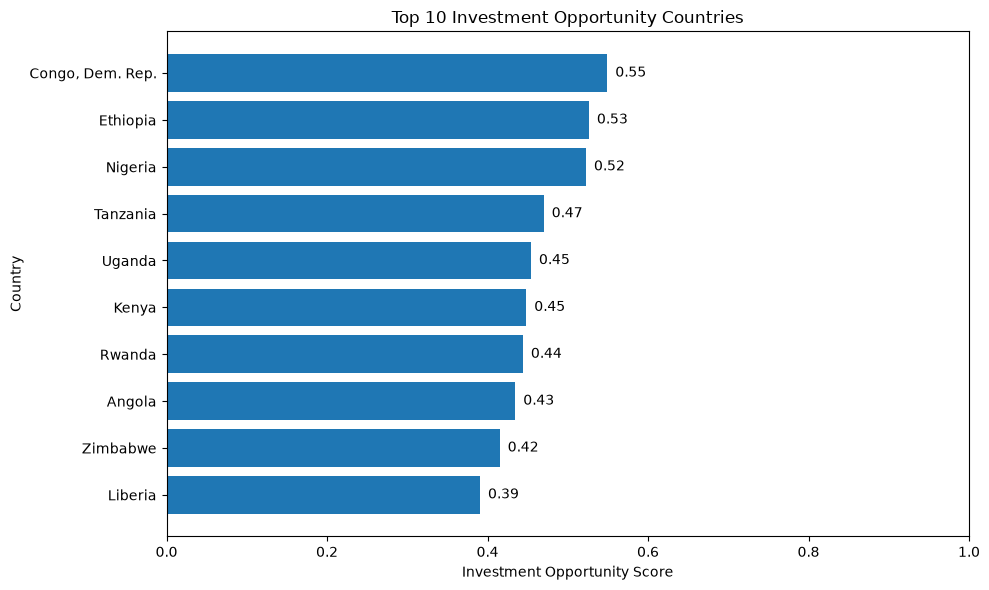

In [20]:
plot_investment_opportunities(ssa_df)

### 6. Compare Version 1 and Version 2 Rankings

Version 1 ranks countries based on electricity need. Version 2 adds GDP per
capita to distinguish development priority from commercial investment
opportunity.

In [21]:
# Create Version 1 and Version 2 rankings
rank_comparison = ssa_df[
    [
        "Country Name",
        "Priority_Score",
        "Investment_Opportunity_Score",
    ]
].copy()

rank_comparison["Version_1_Rank"] = (
    rank_comparison["Priority_Score"]
    .rank(ascending=False, method="min")
)

rank_comparison["Version_2_Rank"] = (
    rank_comparison["Investment_Opportunity_Score"]
    .rank(ascending=False, method="min")
)

rank_comparison["Rank_Change"] = (
    rank_comparison["Version_1_Rank"]
    - rank_comparison["Version_2_Rank"]
)

# Rank_Change interpretation: 
# Positive value: country moved up in Version 2
# Negative value: country moved down
# Zero: no change

rank_comparison = rank_comparison.sort_values(
    "Version_2_Rank"
)

rank_comparison.head(10)

,Country Name,Priority_Score,Investment_Opportunity_Score,Version_1_Rank,Version_2_Rank,Rank_Change
8,"Congo, Dem. Rep.",0.656705,0.549237,1.0,1.0,0.0
13,Ethiopia,0.589611,0.526311,2.0,2.0,0.0
31,Nigeria,0.529784,0.522629,3.0,3.0,0.0
43,Tanzania,0.503015,0.469989,4.0,4.0,0.0
44,Uganda,0.497323,0.454061,5.0,5.0,0.0
20,Kenya,0.438087,0.448243,7.0,6.0,1.0
32,Rwanda,0.479527,0.444037,6.0,7.0,-1.0
0,Angola,0.389021,0.434530,18.0,8.0,10.0
47,Zimbabwe,0.384445,0.415145,19.0,9.0,10.0
21,Liberia,0.430288,0.390571,8.0,10.0,-2.0


A positive rank change means that a country moved upward after GDP per capita
was incorporated. A negative value indicates that the country moved downward.

In [22]:
rank_comparison.sort_values(
    "Rank_Change",
    ascending=False
).head(10)

,Country Name,Priority_Score,Investment_Opportunity_Score,Version_1_Rank,Version_2_Rank,Rank_Change
4,Botswana,0.212917,0.360677,38.0,16.0,22.0
2,Benin,0.351381,0.363859,25.0,14.0,11.0
47,Zimbabwe,0.384445,0.415145,19.0,9.0,10.0
0,Angola,0.389021,0.434530,18.0,8.0,10.0
16,Guinea,0.336767,0.359286,27.0,17.0,10.0
29,Namibia,0.226731,0.335075,34.0,25.0,9.0
19,Equatorial Guinea,0.133686,0.292945,43.0,34.0,9.0
14,Gabon,0.081076,0.261614,46.0,38.0,8.0
40,Seychelles,0.008112,0.256084,48.0,40.0,8.0
39,Eswatini,0.214481,0.319001,36.0,29.0,7.0


In [23]:
rank_comparison.sort_values(
    "Rank_Change",
    ascending=True,
).head(10)

,Country Name,Priority_Score,Investment_Opportunity_Score,Version_1_Rank,Version_2_Rank,Rank_Change
1,Burundi,0.399144,0.299358,13.0,31.0,-18.0
23,Madagascar,0.413857,0.352502,9.0,21.0,-12.0
17,"Gambia, The",0.230617,0.246638,33.0,42.0,-9.0
25,Mozambique,0.397373,0.351277,14.0,22.0,-8.0
28,Malawi,0.399942,0.354229,12.0,19.0,-7.0
30,Niger,0.400895,0.356284,11.0,18.0,-7.0
36,"Somalia, Fed. Rep.",0.209521,0.207966,39.0,46.0,-7.0
5,Central African Republic,0.355761,0.306840,24.0,30.0,-6.0
42,Togo,0.264082,0.288768,29.0,35.0,-6.0
10,Comoros,0.177123,0.245551,40.0,43.0,-3.0


In [24]:
ssa_df = ssa_df.merge(
    rank_comparison[
        [
            "Country Name",
            "Rank_Change",
        ]
    ],
    on="Country Name",
    how="left",
)

The introduction of GDP per capita did not alter the five highest-ranked countries, indicating that severe electricity need remains the dominant driver of opportunity. However, several middle-ranked countries including Botswana, Angola, Zimbabwe, Benin, and Namibia, moved substantially upward because their comparatively stronger economic capacity improved their commercial attractiveness. This demonstrates the distinction between development need and investment opportunity: countries with the greatest electricity deficits are not necessarily the only commercially attractive markets.

# ## 7. Assess Model Consistency
The scatter plot examines whether incorporating GDP fundamentally changes the
model or produces a measured adjustment to the Version 1 results. The largest
ranking movers are labelled.

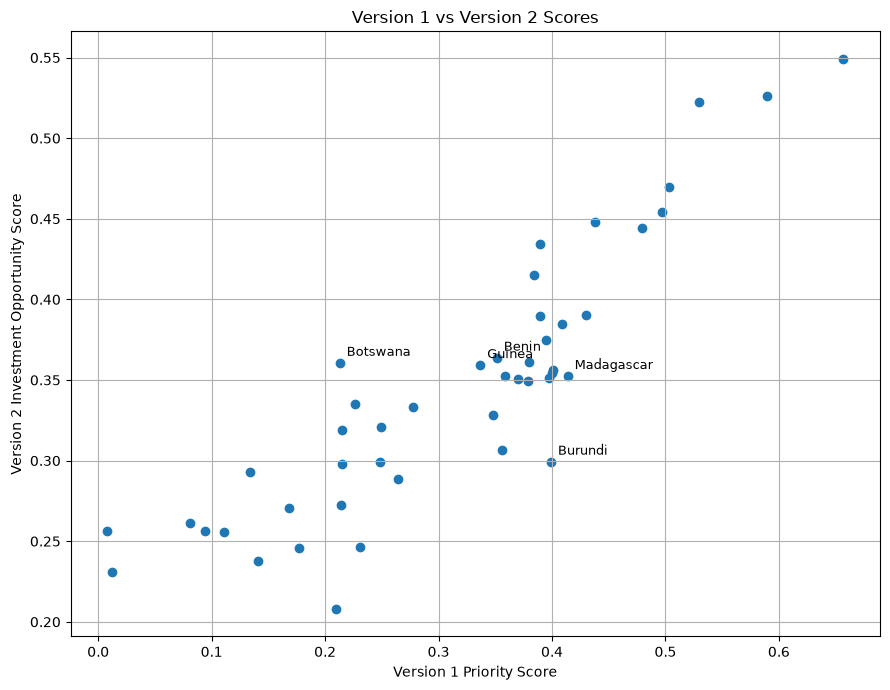

In [25]:
plot_priority_vs_investment(ssa_df)

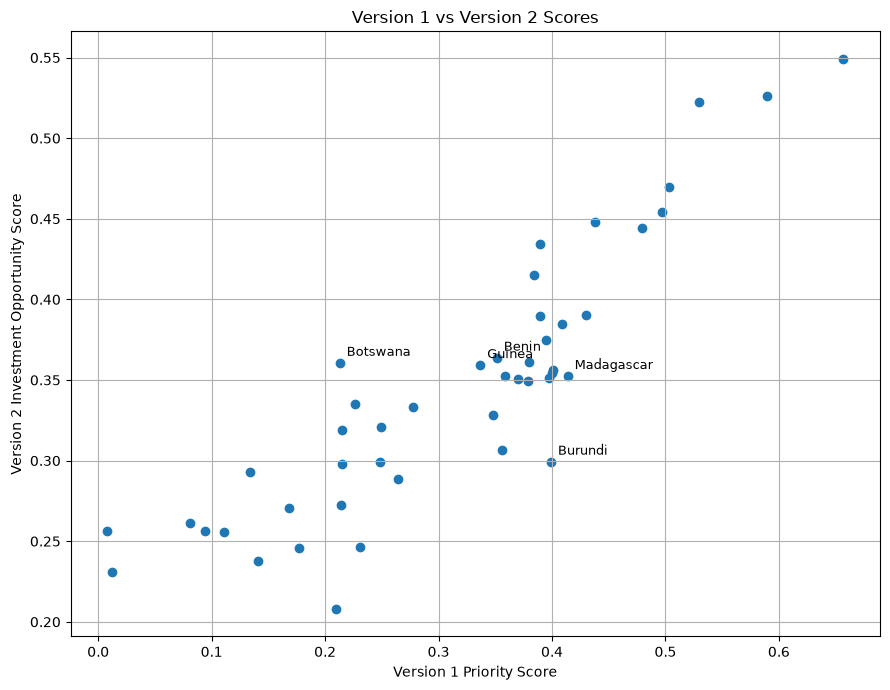

In [26]:
plot_priority_vs_investment(
    ssa_df,
    annotate_top_n=5,
)

In [27]:
# Quantify the relationship with a correlation coefficient

ssa_df[
    [
        "Priority_Score",
        "Investment_Opportunity_Score",
    ]
].corr()

,Priority_Score,Investment_Opportunity_Score
Priority_Score,1.000000,0.886805
Investment_Opportunity_Score,0.886805,1.000000


### 8. Key Findings

1. The five highest-ranked countries—DR Congo, Ethiopia, Nigeria, Tanzania,
    and Uganda—remained unchanged after GDP per capita was introduced. Severe
    electricity need therefore remains the primary driver of the model.

 2. Countries with stronger economic capacity moved upward in the investment
    ranking. Botswana recorded the largest increase, moving from 38th in
    Version 1 to 16th in Version 2.

 3. Angola and Zimbabwe entered the Version 2 top ten after each rose ten
   positions, demonstrating how economic capacity can alter commercial
    attractiveness even when electricity need is less severe.

 4. The correlation between the two model scores is approximately 0.89. The
    models are therefore strongly related, but GDP introduces meaningful
    differences rather than reproducing the original ranking.

 5. The results distinguish development need from commercial opportunity.
    Countries with the greatest electricity deficits are not necessarily the
    only attractive markets for investment.

 6. Eritrea and South Sudan are excluded from GDP-dependent rankings because
    2023 GDP per capita data are unavailable.

### 9. Export the Version 2 Dataset

In [28]:

output_path = (
    project_root
    / "data/processed/ssa_investment_opportunity_v2.csv"
)

ssa_df.to_csv(
    output_path,
    index=False,
)

print(f"Dataset saved to: {output_path}")

Dataset saved to: c:\Users\blue3\Documents\Projects\energy-market-intelligence\data\processed\ssa_investment_opportunity_v2.csv
